# Retrieval-Augmented Generation (RAG) for Corporate Wikis/Documentation


**Authors:** Yasmine Huo, Tracy Ling           
**Team:** Insight Makers

## 1. Introduction

### [Decisions to be impacted]

This project aims to use Retrieval-Augmented Generation (RAG) to build a reliable chatbot for corporate wikis and documentation that produces contextually grounded, precise answers without retraining the underlying language model. 

By utilizing RAG, we can reduce AI hallucinations and the need to retrain LLMs with new data. This would improve development and computational costs on businesses hoping to implement and run LLMs of their own, as well as helping to guarantee increased precision and credibility in their chatbot design because users can personally verify cited sources on their own. This creates better transparency and maintains trustworthiness between a company and its customers. 

The decisions impacted based on this technique cover a wide range of categories, such as: technical decision, operational decisions, governance decisions, and knowledge management decisions. Users use LLMs as a tool for a wide range of activities and based on the LLM response, decisions are made.

### [Business value and Why Do We Care?]

This project is important to us because AI is a huge topic in the present day, with many modes of operation around the world in various sectors of work. The reliance and use of big data is increasing. Rather than focusing solely on model performance, it addresses real-world constraints such as trust, correctness, and usability. Working on this problem allows us to explore how theoretical concepts in natural language processing and data systems translate into practical tools that people can safely rely on.

## 2. Data and Data Pipeline

### [Data]

We use a English Wikipedia data dump snapshot as our primary dataset. The raw data was downloaded from https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-pages-articles.xml.bz2 and was extracted and cleaned using a Python script called WikiExtractor.

### [Data Preprocessing]

##### First Round
**Method:**
1. load a glossary of CS-related terms from `glossary_terms.json`.
2. For each article, we:
- normalized the text by lowercasing and removing extra whitespace
- split the article into **title**, **first two paragraphs**, and **remaining text**
- matched glossary terms in these different regions

**Scoring Rules:**
- title match: +3
- first two paragraphs: +2
- rest of article: +1

**Filtering Rule:**        
An article was kept if:
- its **score was at least 4**, or
- it matched **at least 2 distinct glossary terms**

**Evaluation:**          
We randomly select 100 articles from filtered results and label each article manually as three class:
- **cs**: clearly belongs to core computer science content
- **related**: not purely core CS, but still clearly related to CS / computing / software / AI
- **non_cs**: clearly unrelated and should not be kept


In [29]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

file_path = Path("/Users/hxxy/Desktop/WashU/2026spring/ESE 5971 - Practicum in Data Analytics & Statistics/project/project-rag/data/processed/without_token/first_round/wiki_cs_sample_for_review_labeled.jsonl")

rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

print("Shape:", df.shape)
print(df["manual_label"].value_counts(dropna=False))

non_cs_df = df[df["manual_label"] == "non_cs"].copy()

print("Number of non_cs articles:", len(non_cs_df))

Shape: (100, 8)
manual_label
non_cs     97
related     2
cs          1
Name: count, dtype: int64
Number of non_cs articles: 97


We define the metrics as follows.

- Strict precision:
$$
\text{Strict Precision} = \frac{\#cs}{\#cs + \#related + \#non\_cs}
$$

- Relaxed Precision:

$$
\text{Relaxed Precision} = \frac{\#cs + \#related}{\#cs + \#related + \#non\_cs}
$$
- False Positive Rate:

$$
\text{False Positive Rate} = \frac{\#non\_cs}{\#cs + \#related + \#non\_cs}
$$

## Summary Table

| cs | related | non\_cs | strict precision | relaxed precision | false positive rate |
|---:|---:|---:|---:|---:|---:|
| 1 | 2 | 97 | 0.01 | 0.03 | 0.97 |


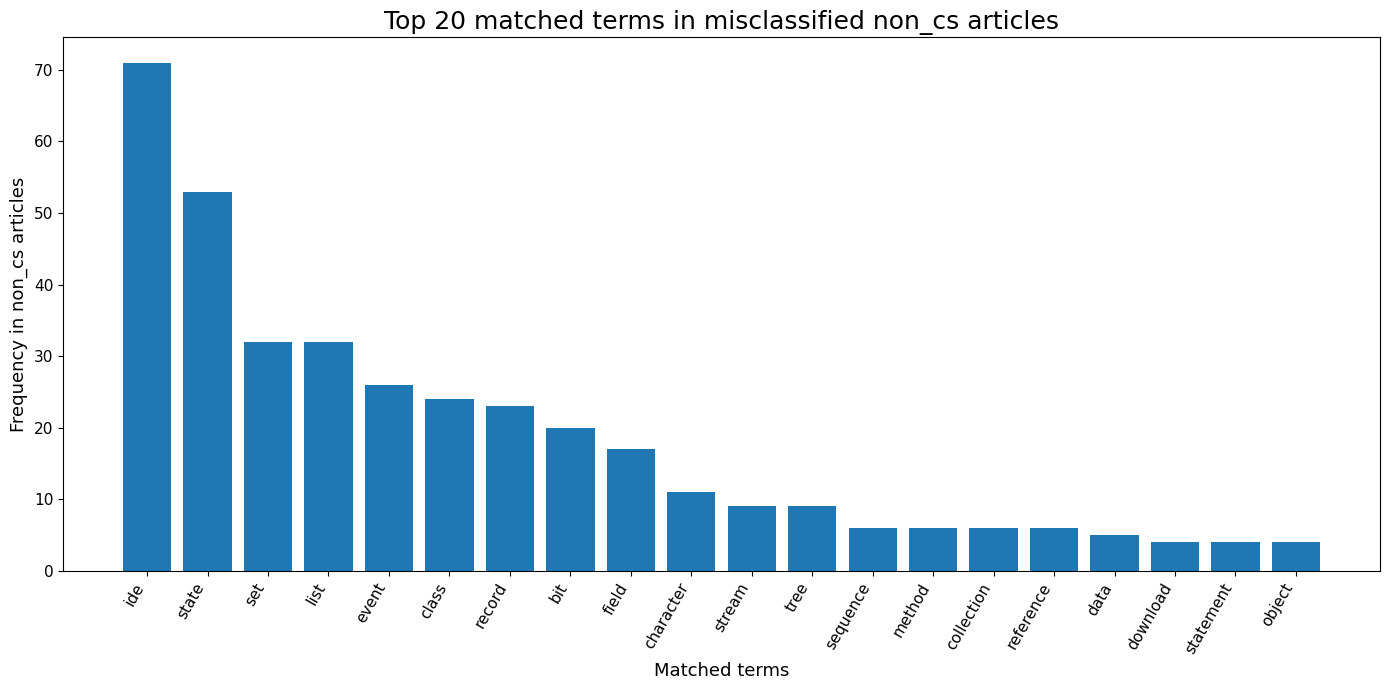

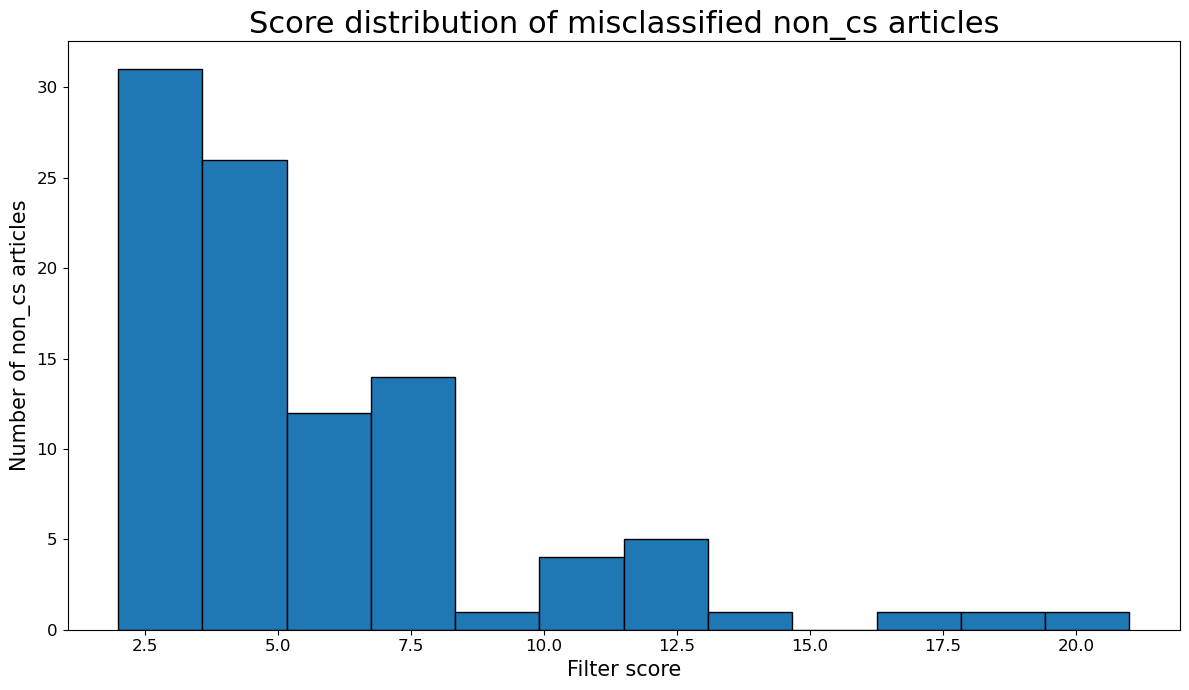

In [20]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

top_n = 20

# -----------------------------
# Figure 1: Top matched terms
# -----------------------------
term_counter = Counter()

for terms in non_cs_df["matched_terms"]:
    if isinstance(terms, list):
        term_counter.update(terms)

top_terms = term_counter.most_common(top_n)
top_terms_df = pd.DataFrame(top_terms, columns=["term", "count"])

plt.figure(figsize=(14, 7))
plt.bar(top_terms_df["term"], top_terms_df["count"])
plt.title(f"Top {top_n} matched terms in misclassified non_cs articles", fontsize=18)
plt.xlabel("Matched terms", fontsize=13)
plt.ylabel("Frequency in non_cs articles", fontsize=13)
plt.xticks(rotation=60, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


# -----------------------------
# Figure 2: Score distribution
# -----------------------------
plt.figure(figsize=(12, 7))
plt.hist(non_cs_df["cs_filter_score"].dropna(), bins=12, edgecolor="black")
plt.title("Score distribution of misclassified non_cs articles", fontsize=22)
plt.xlabel("Filter score", fontsize=15)
plt.ylabel("Number of non_cs articles", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
from pathlib import Path
import pandas as pd

file_path = Path("/Users/hxxy/Desktop/WashU/2026spring/ESE 5971 - Practicum in Data Analytics & Statistics/project/project-rag/data/processed/without_token/first_round/wiki_cs_top_matched_terms.txt")

rows = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        
        # skip title / separator / empty lines
        if not line or line.startswith("Top matched terms") or line.startswith("="):
            continue
        
        term, count = line.split("\t")
        rows.append({"term": term, "count": int(count)})

top_terms_df = pd.DataFrame(rows)

display(top_terms_df)

,term,count
0,ide,2808478
1,state,1717006
2,list,1347568
3,set,1240289
4,event,1075355
...,...,...
195,computability theory,194
196,agile software development,185
197,automata theory,183
198,big o notation,179


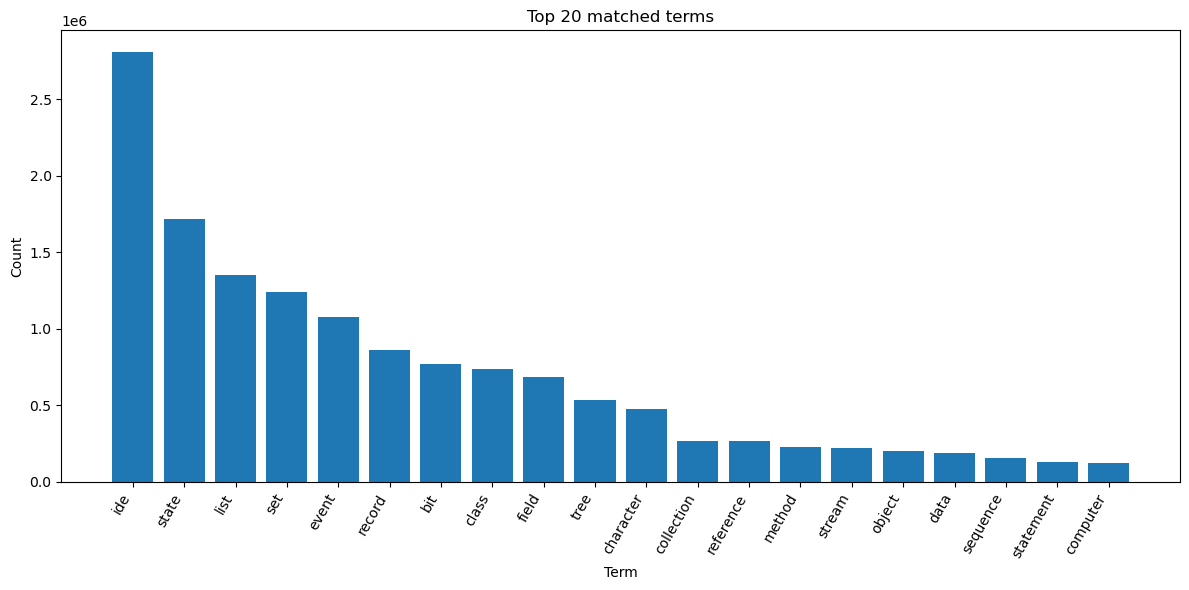

In [5]:
import matplotlib.pyplot as plt

top_n = 20
plot_df = top_terms_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["term"], plot_df["count"])
plt.title(f"Top {top_n} matched terms")
plt.xlabel("Term")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### Problem with the First Filter
The first-round filter was too broad and produced a very high number of false positives.  
From manual review, only a very small portion of the retained articles were actually CS-related, while most were labeled as non-CS.  

The main reason was that the first filter relied on many **broad or ambiguous terms**, such as common words that appear in many non-CS topics.  
As a result, non-CS articles could still receive enough score to pass the filter.

In short, the first filter was useful as a **high-recall coarse screening step**, but its precision was too low to be used as the final domain filter.


##### Second Round

**Method:**
1. load the **first-round filtered articles** from `wiki_cs_articles.jsonl`
2. For each article, we:
   - normalized the text by lowercasing and removing extra whitespace
   - split the article into **title, first two paragraphs, and remaining text**
   - matched terms using two groups:
     - **high-confidence CS terms**
     - **title-only terms** for weaker but still useful signals

**Scoring Rules**:
- **strong title match**: +5
- **strong match in first two paragraphs**: +3
- **strong match in rest of article**: +1
- **title-only weak match**: +1

**Filtering Rule**:     
An article was kept if:
- it had **at least 1 strong title match**, or
- it had **at least 2 strong matches in the first two paragraphs**, or
- it had **at least 3 total strong matches** and a **score of at least 6**

In [7]:
HIGH_CONFIDENCE_TERMS = sorted(set([
    "algorithm",
    "algorithm design",
    "application programming interface",
    "application software",
    "artificial intelligence",
    "ascii",
    "automata theory",
    "bandwidth",
    "benchmark",
    "binary number",
    "bioinformatics",
    "bit rate",
    "booting",
    "boolean algebra",
    "callback",
    "central processing unit",
    "cipher",
    "cloud computing",
    "coding theory",
    "compiler",
    "computation",
    "computability theory",
    "computational biology",
    "computational chemistry",
    "computational complexity theory",
    "computational model",
    "computational neuroscience",
    "computational physics",
    "computational science",
    "computer architecture",
    "computer graphics",
    "computer network",
    "computer programming",
    "computer program",
    "computer science",
    "computer scientist",
    "computer security",
    "computer vision",
    "computing",
    "concurrency",
    "control flow",
    "creative commons",
    "cryptography",
    "csv",
    "cyberspace",
    "data center",
    "data mining",
    "data science",
    "data structure",
    "data type",
    "database",
    "daemon",
    "debugging",
    "digital data",
    "digital signal processing",
    "distributed computing",
    "dns",
    "domain name system",
    "emulator",
    "encryption",
    "executable",
    "exception handling",
    "feasibility study",
    "filename extension",
    "floating-point arithmetic",
    "for loop",
    "formal methods",
    "functional programming",
    "game theory",
    "gigabyte",
    "graph theory",
    "hash function",
    "hash table",
    "human-computer interaction",
    "image processing",
    "information retrieval",
    "input/output",
    "integrated development environment",
    "intelligent agent",
    "interface",
    "interpreter",
    "iteration",
    "java",
    "kernel",
    "linker",
    "linked list",
    "loader",
    "logic programming",
    "machine learning",
    "machine vision",
    "mathematical logic",
    "matrix",
    "modem",
    "natural language processing",
    "node",
    "number theory",
    "numerical analysis",
    "numerical method",
    "object code",
    "object-oriented programming",
    "open-source software",
    "operating system",
    "optical fiber",
    "parallel computing",
    "parameter",
    "peripheral",
    "pointer",
    "programming language",
    "prolog",
    "python",
    "quantum computing",
    "queue",
    "r programming language",
    "radix",
    "recursion",
    "relational database",
    "robotics",
    "router",
    "run time",
    "search algorithm",
    "semantics",
    "serialization",
    "software",
    "software design",
    "software development",
    "software engineering",
    "software testing",
    "source code",
    "stack",
    "subroutine",
    "syntax",
    "technical documentation",
    "type theory",
    "user agent",
    "user interface",
    "user interface design",
    "variable",
    "virtual machine",
    "wi-fi",
    "xhtml",
]))

TITLE_ONLY_TERMS = sorted(set([
    "computer",
    "computing",
    "database",
    "software",
    "compiler",
    "kernel",
    "algorithm",
    "programming language",
    "machine learning",
    "artificial intelligence",
    "computer graphics",
    "computer network",
    "computer vision",
    "data structure",
    "information retrieval",
    "operating system",
    "cryptography",
    "computer architecture",
]))

Shape: (100, 11)
manual_label
related    45
cs         38
non_cs     17
Name: count, dtype: int64
Number of non_cs articles: 17
                       term  count
0               computation      4
1                 computing      4
2                  variable      4
3                 interface      4
4                 algorithm      3
5                      node      3
6                 parameter      3
7   artificial intelligence      2
8                  database      2
9                peripheral      2
10                     java      2
11              game theory      2
12                 software      2
13                   syntax      2
14                    stack      2
15                    ascii      2
16            serialization      2
17         computer program      1
18                   cipher      1
19         computer network      1


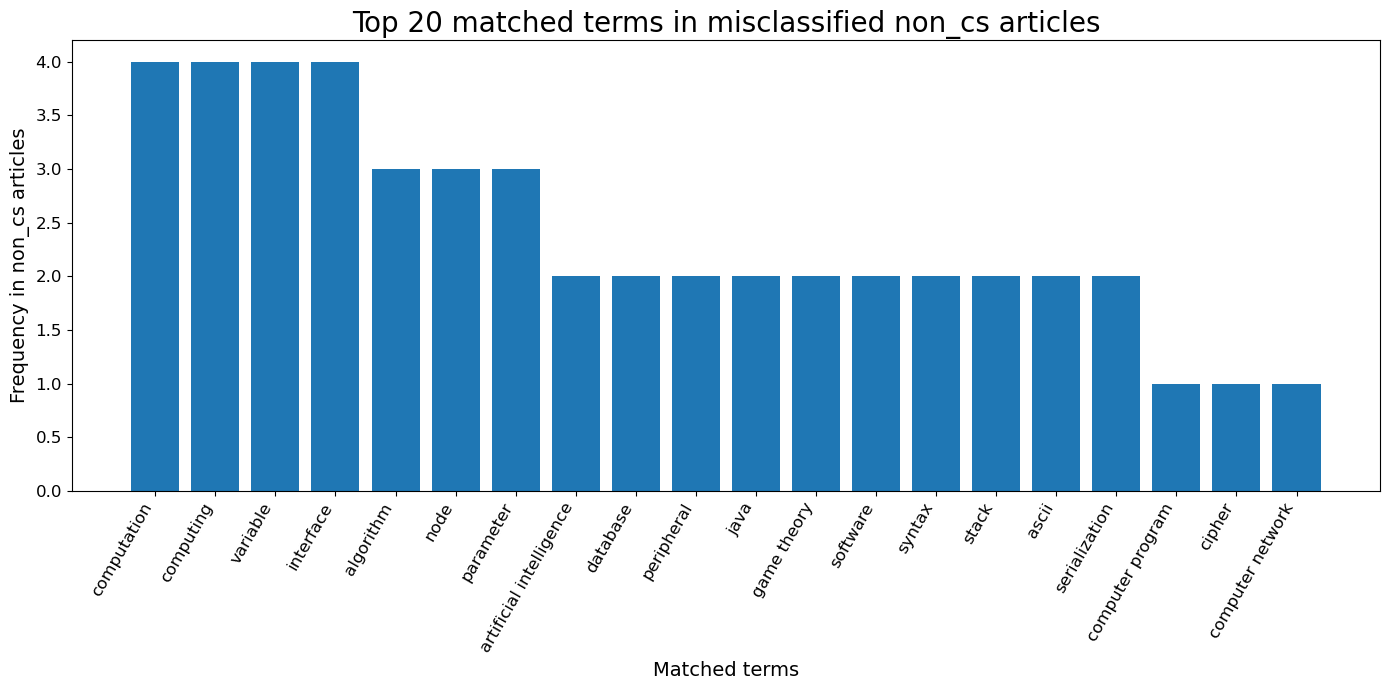

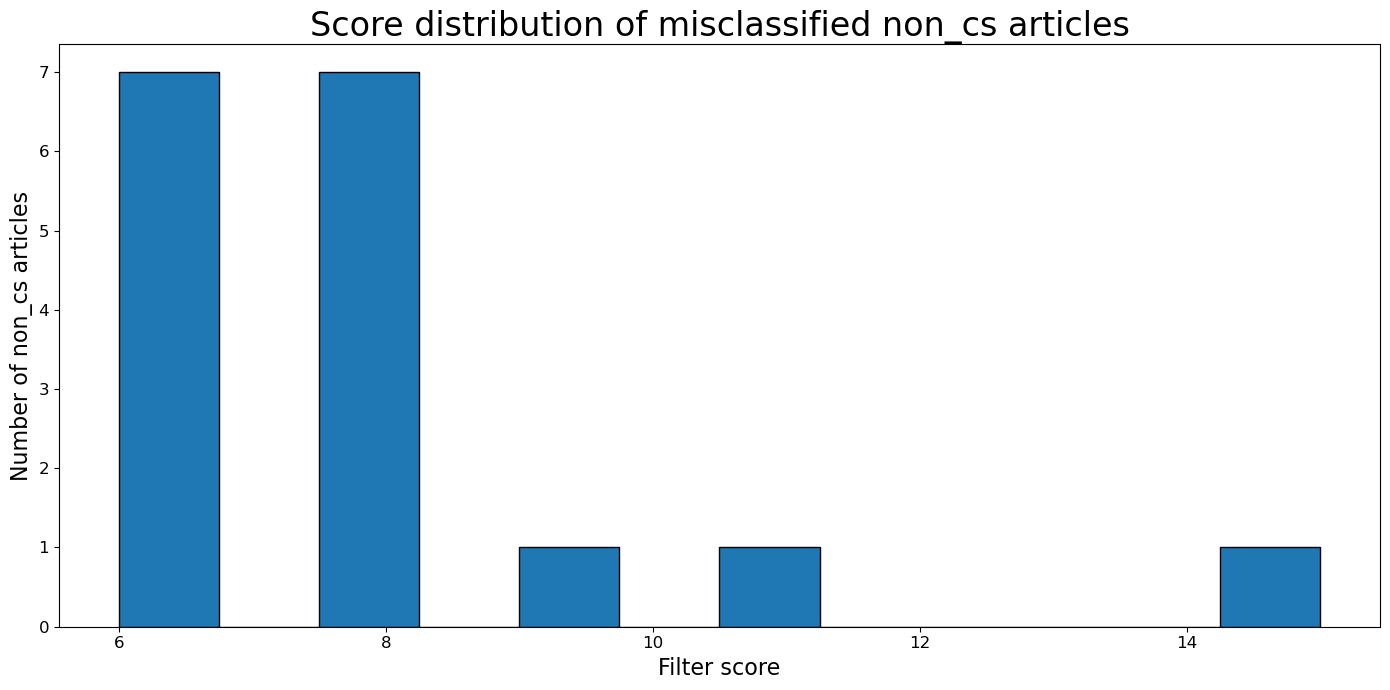

In [16]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File path
# =========================
file_path = Path("/Users/hxxy/Desktop/WashU/2026spring/ESE 5971 - Practicum in Data Analytics & Statistics/project/project-rag/data/processed/without_token/second_round/wiki_cs_v2_sample_for_review_labeled.jsonl")
top_n = 20

# =========================
# Load labeled sample
# =========================
rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

# normalize label text
df["manual_label"] = df["manual_label"].fillna("").str.strip().str.lower()

print("Shape:", df.shape)
print(df["manual_label"].value_counts(dropna=False))

# keep only misclassified false positives
# retained by filter but manually labeled as non_cs
non_cs_df = df[df["manual_label"] == "non_cs"].copy()

print("Number of non_cs articles:", len(non_cs_df))

# =========================
# Figure 1:
# Top 20 matched terms in misclassified non_cs articles
# =========================
term_counter = Counter()

for terms in non_cs_df["matched_terms_v2"]:
    if isinstance(terms, list):
        term_counter.update(terms)

top_terms = term_counter.most_common(top_n)
top_terms_df = pd.DataFrame(top_terms, columns=["term", "count"])

print(top_terms_df)

plt.figure(figsize=(14, 7))
plt.bar(top_terms_df["term"], top_terms_df["count"])
plt.title(f"Top {top_n} matched terms in misclassified non_cs articles", fontsize=20)
plt.xlabel("Matched terms", fontsize=14)
plt.ylabel("Frequency in non_cs articles", fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# Figure 2:
# Score distribution of misclassified non_cs articles
# =========================
plt.figure(figsize=(14, 7))
plt.hist(non_cs_df["cs_filter_score_v2"].dropna(), bins=12, edgecolor="black")
plt.title("Score distribution of misclassified non_cs articles", fontsize=24)
plt.xlabel("Filter score", fontsize=16)
plt.ylabel("Number of non_cs articles", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Summary Table

| cs | related | non\_cs | strict precision | relaxed precision | false positive rate |
|---:|---:|---:|---:|---:|---:|
| 38 | 45 | 17 | 0.38 | 0.83 | 0.17 |

---

                       term  count
0                  software  27305
1                 interface  13678
2                 computing  12932
3                 algorithm  12733
4               computation  10596
5          operating system   9057
6          computer science   8481
7                  database   7997
8                  variable   7589
9                 parameter   6700
10     programming language   6323
11                     node   6269
12                     java   6197
13  artificial intelligence   4936
14           user interface   4702
15                   matrix   4456
16                    stack   4019
17              source code   4002
18       computer scientist   3986
19         computer program   3425


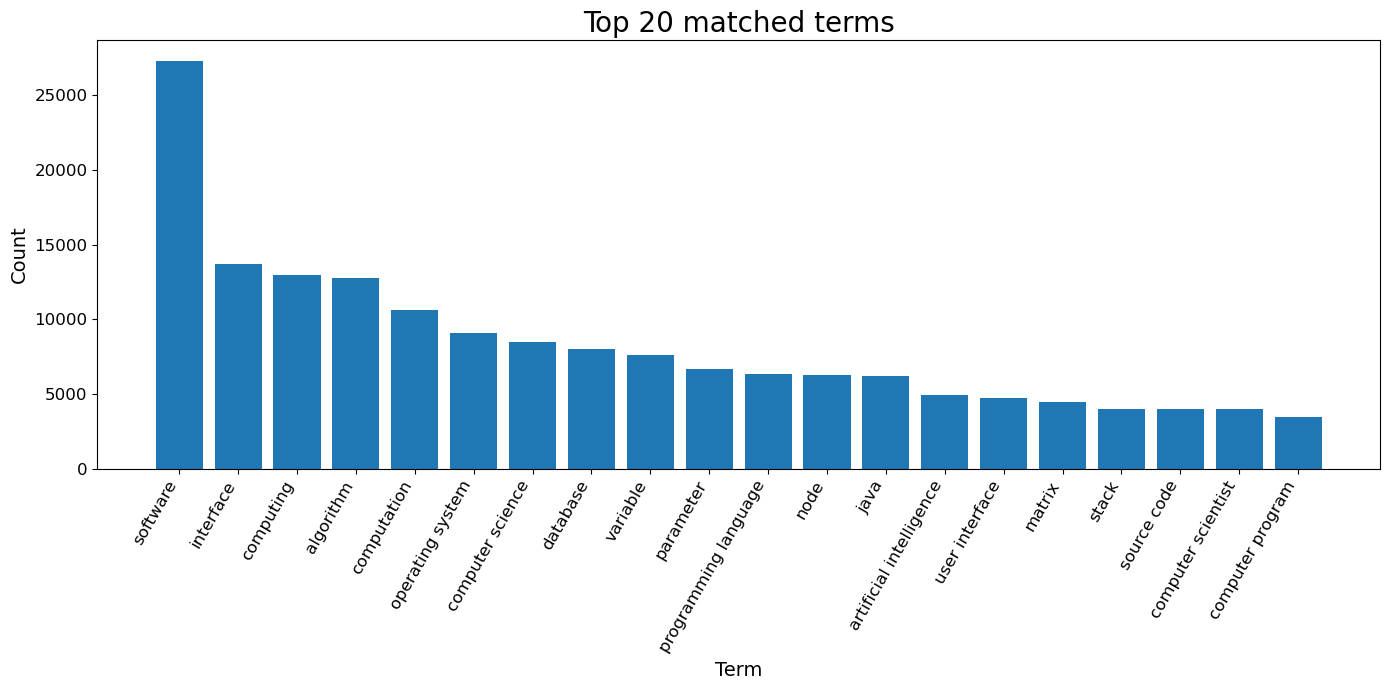

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# file path
file_path = Path("/Users/hxxy/Desktop/WashU/2026spring/ESE 5971 - Practicum in Data Analytics & Statistics/project/project-rag/data/processed/without_token/second_round/wiki_cs_v2_top_matched_terms.txt")
top_n = 20

# read txt
rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        
        # skip header / separator / empty lines
        if not line or line.startswith("Top matched terms") or line.startswith("="):
            continue
        
        term, count = line.split("\t")
        rows.append({"term": term, "count": int(count)})

top_terms_df = pd.DataFrame(rows)

print(top_terms_df.head(top_n))

# plot
plot_df = top_terms_df.head(top_n)

plt.figure(figsize=(14, 7))
plt.bar(plot_df["term"], plot_df["count"])
plt.title(f"Top {top_n} matched terms", fontsize=20)
plt.xlabel("Term", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## Problem with the Second Filter

The second filter still relied on some **broad technical terms**, such as terms that sound highly technical but can also appear in other domains.  
As a result, some non-CS articles could still pass the filter if they contained enough of these terms.

In short, the second filter was effective for building a **higher-quality CS-related corpus**, but it was still not selective enough to produce a **pure core-CS corpus**.

## Third Round

### Method:
1. load the **second-round filtered articles** from `wiki_cs_articles_v2.jsonl`
2. For each article, we:
   - normalized the text by lowercasing and removing extra whitespace
   - split the article into **title, first two paragraphs, and remaining text**
   - matched terms using three groups:
     - **core terms**: strong CS-specific evidence
     - **support terms**: useful but weaker supporting evidence
     - **block or weak terms**: terms that were prone to false positives and should not be used as primary evidence

### Scoring Rules:
- **title core match**: +5
- **first two paragraphs core match**: +3
- **rest of article core match**: +1
- **title support match**: +1
- **first two paragraphs support match**: +1

### Filtering Rule:
An article was kept if:
- it had **at least 1 core match in the title**, or
- it had **at least 2 core matches in the first two paragraphs**, or
- it had **at least 2 total core matches** and a **score of at least 6**


In [ ]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

file_path = Path("/Users/hxxy/Desktop/WashU/2026spring/ESE 5971 - Practicum in Data Analytics & Statistics/project/project-rag/data/processed/without_token/third_round/wiki_cs_v3_sample_for_review_labeled.jsonl")

rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

print("Shape:", df.shape)
print(df["manual_label"].value_counts(dropna=False))

non_cs_df = df[df["manual_label"] == "non_cs"].copy()

print("Number of non_cs articles:", len(non_cs_df))

Shape: (100, 10)
manual_label
cs         67
related    31
non_cs      2
Name: count, dtype: int64
Number of non_cs articles: 2


### Summary Table

| cs | related | non\_cs | strict precision | relaxed precision | false positive rate |
|---:|---:|---:|---:|---:|---:|
| 67 | 31 | 2 | 0.67 | 0.98 | 0.02 |

| Review Stage | cs | related | non\_cs | strict precision | relaxed precision | false positive rate |
|---|---:|---:|---:|---:|---:|---:|
|first round| 1 | 2 | 97 | 0.01 | 0.03 | 0.97 |
|second round| 38 | 45 | 17 | 0.38 | 0.83 | 0.17 |
|third round| 67 | 31 | 2 | 0.67 | 0.98 | 0.02 |

## [Chunk Construction]

To prepare the filtered Wikipedia articles for retrieval, we converted the article-level dataset `wiki_cs_articles_v3.jsonl` into a chunk-level corpus. The goal of this step was to transform each full article into smaller, semantically meaningful text units while preserving useful structural metadata for downstream retrieval. 

### Input and Output

- **Input file:** `data/processed/third_round/wiki_cs_articles_v3.jsonl`
- **Output file:** `data/processed/corpus_chunks_filtered.jsonl`

- Each line in the input file represents one filtered Wikipedia article.
- Each line in the output file represents one chunk derived from an article paragraph or sub-paragraph. 

### Overall Procedure

- Read the filtered articles from the JSONL file one by one.
- Extract key metadata from each article, including:
  - `page_id`
  - `title`
  - `revid`
  - `url`
  - `text`
- Parse the article text into sections and paragraphs.
- Preserve structural information such as section hierarchy.
- Split long paragraphs into smaller sub-chunks when necessary.
- Assign a stable chunk ID to each chunk.
- Write all chunks and their metadata into a new chunk-level JSONL file. 

### Article Reading

- The script reads the input JSONL file line by line rather than loading the full file into memory.
- Each valid line is parsed as a JSON article record.
- Empty lines and malformed JSON lines are skipped.
- This design makes the pipeline more memory-efficient for large corpora. 

### Metadata Extraction

For each article, the script extracts the following fields:

- `id` → stored as `page_id`
- `title`
- `revid`
- `url`
- `text`

These metadata fields are later copied into every chunk so that each chunk remains traceable to its source article. 

### Section and Paragraph Parsing

The script uses a structure-aware parsing strategy rather than splitting text with a fixed window only.

- It supports **explicit Wikipedia headings**, such as:
  - `== History ==`
  - `=== Applications ===`

- It also supports **cleaned heading lines** commonly produced by WikiExtractor, such as:
  - `History.`
  - `Architecture.`
  - `Applications.`

- For each detected heading, the script updates the current section path.
- For each normal text line, the script treats it as a paragraph candidate.
- Only paragraphs with at least 40 characters are kept, which helps remove very short or uninformative fragments. 

### Section Path Representation

- If a paragraph belongs to a recognized section, the script records its hierarchical section path.
- Examples:
  - `["History"]`
  - `["Architecture", "Memory management"]`

- If no heading is detected for a paragraph, the script assigns:
  - `["(root)"]`

This ensures that every chunk has a consistent structural field, even when the original article has no clearly detected section headings. 

### Long Paragraph Splitting

To keep chunks at a manageable size for embedding and retrieval:

- Each paragraph is checked against a maximum length of **1200 characters**.
- If the paragraph is shorter than this threshold, it is kept as a single chunk.
- If the paragraph is longer, it is split into smaller sub-chunks.

The splitting strategy is semi-structured:

- The script first tries to cut at a natural boundary, such as:
  - a sentence boundary (`". "`)
  - a newline
- If no good boundary is found, it falls back to a hard cut near the length limit.

This approach helps preserve semantic coherence better than a purely fixed-width split. 

### Stable Chunk ID Generation

Each chunk is assigned a deterministic chunk ID based on:

- `page_id`
- `title`
- `section_path`
- `paragraph_index`
- `sub_chunk_index`

The script hashes this information with MD5 and creates an ID of the form:

- `wiki_<hash>`

This design ensures that:

- chunk IDs are unique
- chunk IDs are reproducible across runs
- the same article and paragraph structure will yield the same chunk IDs if the input remains unchanged 

### Output Chunk Format

Each output chunk includes the following fields:

- `chunk_id`
- `page_id`
- `title`
- `section_path`
- `paragraph_index`
- `text`
- `source`
- `url`
- `revid`

This format preserves both the chunk text and its provenance, which is useful for retrieval, evidence tracing, and answer generation in the RAG pipeline. 

## 3. Model/Solution Performance

These two scripts implement a **basic retrieval-augmented question answering pipeline**:

1. `vector.py`  
   - reads chunked CS-related Wikipedia data from `corpus_chunks_filtered.jsonl`
   - converts each chunk into a LangChain `Document`
   - embeds the documents with an embedding model
   - stores them in a Chroma vector database
   - creates a retriever for semantic search

In [ ]:
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_ollama.llms import OllamaLLM
from langchain_core.documents import Document
import os
import pandas as pd

embeddings = OllamaEmbeddings(model="mxbai-embed-large")
db_loc = "data/chroma_db"
SIMILARITY_THRESHOLD = 0.75

def load_documents():
    """Loads documents from the processed corpus JSONL file and returns a list of Document objects and their corresponding IDs."""
    df = pd.read_json("data/processed/corpus_chunks_filtered.jsonl", lines=True)
    documents = []
    ids = []
    
    for i, row in df.iterrows():
        doc = Document(
            page_content=(
                row["title"] + " | " + 
                " > ".join(row["section_path"]) + " | " +
                row["text"]),
            metadata={"url": row["url"]},
            id=str(i)
        )
        ids.append(str(i))
        documents.append(doc)
    return documents, ids

def initialize_vector_store():
    """Initializes the Chroma vector store. If the store already exists, it will be loaded.
    If it does not exist, it will be created and populated with documents."""
    add_documents = not os.path.exists(db_loc)
    vector_store = Chroma(
        collection_name="wikipedia_cs",
        persist_directory=db_loc,
        embedding_function=embeddings,
    )
    
    # Embedding step: only add documents if the vector store is not already built
    if add_documents:
        documents, ids = load_documents()
        vector_store.add_documents(documents=documents, ids=ids)

    return vector_store

vector_store = initialize_vector_store()


classifier_model = OllamaLLM(model="qwen2.5:1.5b")

def is_computer_science(doc) -> bool:
    """
    Uses an LLM to determine whether a document is CS-related.
    Returns True/False.
    """

    prompt = f"""
    You are a strict classifier.

    Determine whether the following text is about COMPUTER SCIENCE.

    Computer science includes:
    - algorithms
    - data structures
    - operating systems
    - databases
    - networks
    - programming languages
    - software systems
    - computer architecture
    - artificial intelligence
    - machine learning
    - theoretical CS concepts (complexity, computability, etc.)

    If the text is about biology, medicine, chemistry, physics (non-CS), or general science, answer NO.

    Return ONLY one word: YES or NO.

    TEXT:
    {doc.page_content}
    """

    result = classifier_model.invoke(prompt).strip().upper()

    return "YES" in result


# ----------------------------
# RETRIEVAL WITH FILTERING
# ----------------------------
def retrieve_filtered(query, k=5):
    """
    1. Retrieve candidates via embeddings
    2. Filter by similarity
    3. Filter by CS domain classifier
    """

    results = vector_store.similarity_search_with_score(query, k=k * 10)
    filtered_docs = []

    for doc, score in results:

        # STEP 1: similarity filter (embedding-based)
        if score > (1 - SIMILARITY_THRESHOLD):
            continue

        # STEP 2: semantic domain filter (NO keywords)
        if not is_computer_science(doc):
            continue

        filtered_docs.append(doc)

        if len(filtered_docs) >= k:
            break

    return filtered_docs
    
# Connect LLM with vector store
class RetrieverWrapper:
    def invoke(self, query):
        return retrieve_filtered(query)

retriever = RetrieverWrapper()


2. `answer.py`  
   - imports the retriever created in `vector.py`
   - loads an LLM (`qwen2.5:3b`) through Ollama
   - retrieves the top relevant chunks for a user question
   - injects those chunks into a prompt
   - asks the model to answer using only the retrieved context

In [ ]:
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from src.retrieval.vector import retriever

model = OllamaLLM(model="qwen2.5:3b")

template = """
You are a highly reliable computer science specialist designed to answer questions strictly using the provided Wikipedia Computer Science articles.

---

# 1. KNOWLEDGE SOURCE RULE
- You MUST ONLY use the provided Wikipedia articles.
- Do NOT use external knowledge or assumptions.
- If the answer is not supported by the articles, respond EXACTLY:
  I don't know based on the provided context.
- Some articles contain information related to other subjects such as Biology or Chemistry. You MUST IGNORE any information that is not relevant to Computer Science, even if it appears in the provided articles.
- 

---

# 2. ANSWER REQUIREMENTS
- Be clear, concise, and technically correct.
- Use only information found in the provided context.
- Do NOT invent facts.
- Prefer structured explanations when helpful (bullet points or steps).

---

# 3. CITATION RULES (VERY IMPORTANT)
- Every factual claim MUST be supported by at least one source.
- You MUST include source numbers [1], [2], etc. that appear in the context.
- You MUST also include the exact URL from the cited article.
- Do NOT fabricate or modify URLs.

---

# 4. CRITICAL FORMATTING RULE (STRICT ORDER)

Your response MUST follow this exact structure:

## Answer:
<your answer here>

## Sources:
<your sources here>

Rules:
- The FIRST line of your response MUST be "## Answer:"
- Do NOT output ANY sources before the Answer section
- Do NOT repeat sources inside the Answer section
- The Sources section MUST appear only once at the end

---

# 5. SOURCES FORMAT (MANDATORY)

If you used any article, format like this ONLY AFTER the "## Sources:" section:

[1] https://en.wikipedia.org/wiki/Process_(computing)
[2] https://en.wikipedia.org/wiki/Thread_(computer_science)

Rules:
- Include ALL articles used to form the answer
- Copy URLs EXACTLY from the context
- Do NOT rewrite or shorten URLs

---

# 6. WHEN NO SOURCES ARE USED

Only output:
Sources: None

ONLY if the answer is:
"I don't know based on the provided context."

---

# 7. PROVIDED WIKIPEDIA ARTICLES:
{articles}

---

# QUESTION:
{question}

---

Now answer using ONLY the provided articles.
"""

prompt = ChatPromptTemplate.from_template(template)
chain = prompt | model

def format_articles(docs):
    formatted = []

    for i, doc in enumerate(docs, start=1):
        metadata = doc.metadata

        title = metadata.get("title", "Unknown")
        url = metadata.get("url", "Unknown")

        formatted.append(
            f"[{i}] {title} | {url}\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(formatted)


if __name__ == "__main__":
    while True:
        print("\n\n------------------------------")
        question = input("Ask a question (or type 'exit' to quit): ")
        print("\n\n------------------------------")

        if question.lower() in ["exit", "quit"]:
            break

        docs = retriever.invoke(question)

        articles = format_articles(docs)

        result = chain.invoke({
            "articles": articles,
            "question": question
        })

        print(result)

Together, the two files form a simple end-to-end RAG system:

**Pipeline:** Build vector store -> Retrieve relevant chunks -> Generate answer from retrieved context

## Evaluation Metric: DeepEval (G-Eval)

In [ ]:
import pandas as pd
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval import evaluate
from deepeval.metrics import GEval
from src.generation.answer import chain
from src.retrieval.vector import retriever


queries = pd.read_json("eval/queries.jsonl", lines=True)
sample_queries = list(queries["question"])
# print(sample_queries)

answers = pd.read_json("eval/answers.jsonl", lines=True)
expected_answers = list(answers["answer"])

###########################
# DeepEval Implementation 
###########################

correctness_metric = GEval(
    name="Correctness",
    criteria=(
        "The answer must correctly match the expected answer in meaning, "
        "including key computer science concepts, definitions, and relationships. "
        "Paraphrasing is allowed only if the technical meaning is preserved without loss of important details."
    ),
    evaluation_steps=[
        "Compare the chatbot answer to the expected answer.",
        "Allow paraphrasing if technical meaning is preserved.",
        "Penalize incorrect computer science facts.",
        "Penalize missing key technical details.",
        "Penalize contradictions heavily."
    ],
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT],
)

faithfulness_metric = GEval(
    name="Faithfulness",
    criteria=(
        "The answer must be fully supported by the retrieved Wikipedia computer science context. "
        "No external knowledge, assumptions, or hallucinated facts are allowed."
    ),
    evaluation_steps=[
        "Extract factual claims from the chatbot response.",
        "Check whether every claim is supported by the retrieved Wikipedia context.",
        "Claims may include definitions, algorithms, complexity classes, architectures, networking facts, data structures, programming languages, or historical CS facts.",
        "Penalize hallucinated claims heavily.",
        "Penalize contradictions with retrieved context heavily.",
        "Reward answers that stay grounded only in retrieved context."
    ],
    evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.RETRIEVAL_CONTEXT],
)

context_precision_recall_metric = GEval(
    name="Context Precision Recall",
    criteria=(
        "The retrieved context must be both relevant and sufficient to answer the question. "
        "It should include necessary computer science concepts while avoiding irrelevant information."
    ),
    evaluation_steps=[
        "Determine whether retrieved context is relevant to the question.",
        "Precision: penalize irrelevant passages or noisy retrieved chunks.",
        "Recall: penalize if essential information needed for the expected answer is missing.",
        "Reward context that is focused and sufficiently complete.",
        "For technical questions, verify that required definitions, examples, formulas, or algorithm details are present."
    ],
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.RETRIEVAL_CONTEXT,LLMTestCaseParams.EXPECTED_OUTPUT],
)

test_cases = []

for question, expected in zip(sample_queries, expected_answers):
    # Retrieve docs
    docs = retriever.invoke(question)

    # Convert to plain text context
    retrieval_context = [doc.page_content for doc in docs]

    # Generate answer using RAG chain
    actual_output = chain.invoke({
        "articles": docs,
        "question": question
    })

    test_case = LLMTestCase(
        input=question,
        actual_output=actual_output,
        expected_output=expected,
        retrieval_context=retrieval_context
    )

    test_cases.append(test_case)

####################
# Run Evaluation
####################

evaluate(
    test_cases=test_cases,
    metrics=[
        correctness_metric,
        faithfulness_metric,
        context_precision_recall_metric
    ]
)

## 4. Conclusion and Insights